# Sommaire Interactif

* [1. Installation des bibliothèques et imports](#partie1)
* [2. Initialisation des constantes globales](#partie2)
* [3. Chargement des données](#partie3)
* [4. Logique de Prétraitement](#partie4)
* [5. Définition du Modèle](#partie5)
* [6. Générateur de Données avec Augmentation](#partie6)
* [7. Logique d'Entraînement](#partie7)
* [8. Lancement de l'Entraînement](#partie8)
* [9. Logique de Vérification (Inférence)](#partie9)
* [10. Test Final de Bout en Bout](#partie10)
* [11. Tracé de la Courbe ROC et Calibration](#partie11)


<a id="partie1"></a>
# 1. Installation des bibliothèques et imports
 
Durant ce notebook, on travaille avec keras de tensorflow et opencv notamment. 

In [2]:
#%uv pip install tensorflow

Using Python 3.12.6 environment at: /usr/local
Resolved 38 packages in 295ms
⠙ Preparing packages... (0/7)
⠙ Preparing packages... (0/7)
⠙ Preparing packages... (0/7)
termcolor  ------------------------------ 7.52 KiB/7.52 KiB
⠙ Preparing packages... (0/7)
termcolor  ------------------------------ 7.52 KiB/7.52 KiB
⠙ Preparing packages... (0/7)
termcolor  ------------------------------ 7.52 KiB/7.52 KiB
astunparse ------------------------------     0 B/12.43 KiB
⠙ Preparing packages... (0/7)
termcolor  ------------------------------ 7.52 KiB/7.52 KiB
astunparse ------------------------------ 12.43 KiB/12.43 KiB
⠙ Preparing packages... (0/7)
termcolor  ------------------------------ 7.52 KiB/7.52 KiB
astunparse ------------------------------ 12.43 KiB/12.43 KiB
gast       ------------------------------ 14.92 KiB/20.68 KiB
⠙ Preparing packages... (0/7)
termcolor  ------------------------------ 7.52 KiB/7.52 KiB
astunparse ------------------------------ 12.43 KiB/12.43 KiB
gast       ----

In [3]:
#%uv pip install opencv-python matplotlib scikit-learn

Using Python 3.12.6 environment at: /usr/local
Resolved 16 packages in 162ms
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠙ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠹ Preparing packages... (0/1)
⠸ Preparing packages... (0/1)
⠸ Preparing packages... (0/1)
⠸ Preparing packages... (0/1)
⠼ Preparing packages... (0/1)
⠼ Preparing packages... (0/1)
⠼ Preparing packages...

In [1]:
# --- Cellule 1: Imports ---
import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Conv2D, BatchNormalization, ReLU, MaxPooling2D,
    GlobalAveragePooling2D, Dense, Lambda, Concatenate
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
import numpy as np
import cv2  # OpenCV pour le traitement d'images
import os
import random
import glob

# Afficher la version de TensorFlow
print(f"TensorFlow Version: {tf.__version__}")

2025-11-18 14:53:37.651179: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-18 14:53:37.743777: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow Version: 2.20.0


<a id="partie2"></a>
## 2. Initialisation des constantes globales

On choisit un nombre d'epoch faible (10) en premier lieu pour un entraînement rapide.
Le batch_size est choisit à 16 car on a utilisé un GPU pour l'entraînement.

Les paramètres des fichiers n'existent pas encore mais vont être téléchargé/unzip avec les prochaines cellules.

In [ ]:
# --- Cellule 2: Constantes Globales ---

# Paramètres des images
IMG_HEIGHT = 128
IMG_WIDTH = 256
CHANNELS = 1

# Paramètres du modèle
EMBEDDING_DIM = 128 

# Paramètres d'entraînement
BATCH_SIZE = 16 # Utilisation d'un GPU pour ce notebook
LEARNING_RATE = 0.0001
EPOCHS = 10 # 10 époques pour un test rapide
TRIPLET_MARGIN = 0.5 

# Paramètres des Fichiers
TRAIN_DIR = "data/train"
VALID_DIR = "data/validation"
MODEL_PATH = "models/encoder.keras" 

<a id="partie3"></a>
## 3. Chargement des données

Les données sont stockées dans le fichier *data.zip*.\
On va extraîre ces données et tester la structure du dossier.

Le dossier *data.zip* contient 2 dossiers *train* et *validation*, contenant respectivement 50 et 14 auteurs.\
Les auteurs de *train* ont au 12 ou 24 signatures chacun, les auteurs de *validation* ont chacun 12 signatures.


In [ ]:
# --- Cellule 3: Chargement et Décompression des Données Réelles ---
import os

# Nom denotrefichier zip (changez-le si nécessaire)
ZIP_FILE_NAME = "data.zip"

# S'assurer que le fichier zip est bien présent
if not os.path.exists(ZIP_FILE_NAME):
    print(f"ERREUR: Fichier '{ZIP_FILE_NAME}' non trouvé.")
    print(".zip à importer dans le panneau de gauche avant d'exécuter.")
else:
    print(f"Fichier '{ZIP_FILE_NAME}' trouvé.")


    # Nettoyer les anciens dossiers (au cas où)
    !rm -rf data/
    
    # Décompresser le fichier (-q = quiet, pour moins de logs)
    print("Décompression en cours...")
    !unzip -q {ZIP_FILE_NAME}
    print("Décompression terminée.")
    
    # --- Vérification Critique ---
    # Nous devons nous assurer que la structure de dossiers est correcte
    
    print("\n--- Vérification de la structure des dossiers ---")
    if os.path.exists(TRAIN_DIR) and os.path.exists(VALID_DIR):
        print(f"Structure de dossiers '{TRAIN_DIR}' et '{VALID_DIR}' trouvée. C'est parfait.")
        
        print("\nAperçu de notre dossier d'entraînement (data/train/):")
        # Montre les 10 premiers dossiers d'auteurs
        !ls -l data/train/ | head
        
        print("\nAperçu de notre dossier de validation (data/validation/):")
        # Montre les 10 premiers dossiers d'auteurs
        !ls -l data/validation/ | head
        
    else:
        print("ERREUR DE STRUCTURE :")
        print(f"Je m'attendais à trouver les dossiers '{TRAIN_DIR}' et '{VALID_DIR}'.")
        print("Le fichier .zip ne contient peut-être pas la bonne arborescence.")
        print("Contenu actuel du dossier 'data/' (s'il existe):")
        !ls -l data/

Fichier 'data.zip' trouvé.
Décompression en cours...
Décompression terminée.

--- Vérification de la structure des dossiers ---
Structure de dossiers 'data/train' et 'data/validation' trouvée. C'est parfait.

Aperçu de votre dossier d'entraînement (data/train/):
total 25
drwxrwxrwx 2 root root 6 Nov 17 15:57 001
drwxrwxrwx 2 root root 6 Nov 17 15:57 002
drwxrwxrwx 2 root root 6 Nov 17 15:57 003
drwxrwxrwx 2 root root 6 Nov 17 15:57 004
drwxrwxrwx 2 root root 6 Nov 17 15:57 006
drwxrwxrwx 2 root root 6 Nov 17 15:57 009
drwxrwxrwx 2 root root 6 Nov 17 15:57 012
drwxrwxrwx 2 root root 6 Nov 17 15:57 013
drwxrwxrwx 2 root root 6 Nov 17 15:57 014

Aperçu de votre dossier de validation (data/validation/):
total 7
drwxrwxrwx 2 root root 6 Nov 17 16:04 056
drwxrwxrwx 2 root root 6 Nov 17 15:57 057
drwxrwxrwx 2 root root 6 Nov 17 15:57 058
drwxrwxrwx 2 root root 6 Nov 17 16:04 059
drwxrwxrwx 2 root root 6 Nov 17 16:04 060
drwxrwxrwx 2 root root 6 Nov 17 15:57 061
drwxrwxrwx 2 root root 6 Nov 17

<a id="partie4"></a>
## 4. Prétraitement 

On implémente une fonction pour charger, nettoyer et prépare une image.\
Dans le prétraitement, on va redimensionner, binariser, normaliser les valeurs de pixel et et ajouter la dimension du canal.

In [ ]:
# --- Cellule 4: Logique de Prétraitement ---

def preprocess_image(image_path):
    """
    Charge, nettoie, et prépare une seule image.
    """
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    
    # Redimensionner
    img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
    
    # Binarisation (Inversée, car notre image fictive a du texte blanc)
    _, img = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # Normaliser les valeurs de pixel
    img = img.astype(np.float32) / 255.0
    
    # Ajouter la dimension du canal
    img = np.expand_dims(img, axis=-1)
    
    return img

<a id="partie5"></a>
## 5. Définition du modèle

On construit un CNN qui transforme une image (H, W, 1) en un vecteur d'embedding (128).\
L'image passe par 4 blocs successifs de Conv2D, BatchNormalisation, ReLU et MaxPooling.

On applique à la fin une couche personnalisée pour la normalisation. 

In [ ]:
# --- Cellule 5: Définition du Modèle ---

@tf.keras.utils.register_keras_serializable()
class L2NormalizeLayer(tf.keras.layers.Layer):
    """Couche personnalisée pour effectuer la normalisation L2."""
    def __init__(self, **kwargs):
        super(L2NormalizeLayer, self).__init__(**kwargs)
    
    def call(self, inputs):
        """L'action de la couche : normaliser le vecteur."""
        # On utilise tf.math.l2_normalize
        return tf.math.l2_normalize(inputs, axis=1)
        
    def get_config(self):
        """Permet à Keras de sauvegarder et charger cette couche."""
        base_config = super(L2NormalizeLayer, self).get_config()
        return base_config

def build_encoder_model():
    """
    Construit le modèle CNN qui transforme une image (H, W, 1) 
    en un vecteur d'embedding (128).
    """
    img_input = Input(shape=(IMG_HEIGHT, IMG_WIDTH, CHANNELS), name="image_input")

    # Blocs Convolutifs
    x = Conv2D(32, (3, 3), padding='same')(img_input)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(64, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D((2, 2))(x)

    x = Conv2D(128, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D((2, 2))(x)
    
    x = Conv2D(256, (3, 3), padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D((2, 2))(x)

    # Tête du modèle
    x = GlobalAveragePooling2D()(x)
    x = Dense(EMBEDDING_DIM, activation=None)(x)
    
    # Remplacer la Lambda fragile par notre couche personnalisée robuste
    x = L2NormalizeLayer(name="embedding")(x)

    encoder = Model(inputs=img_input, outputs=x, name="encoder")
    return encoder

# Tester la construction
encoder_test = build_encoder_model()
encoder_test.summary()
del encoder_test # Nettoyer

I0000 00:00:1763477635.177450     613 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13759 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:18:00.0, compute capability: 7.5
I0000 00:00:1763477635.180264     613 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13759 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:19:00.0, compute capability: 7.5
I0000 00:00:1763477635.182699     613 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 13759 MB memory:  -> device: 2, name: Tesla T4, pci bus id: 0000:35:00.0, compute capability: 7.5
I0000 00:00:1763477635.184505     613 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 13759 MB memory:  -> device: 3, name: Tesla T4, pci bus id: 0000:36:00.0, compute capability: 7.5


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)             │ (None, 128, 256, 1)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 128, 256, 32)        │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128, 256, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 128, 256, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 128, 32)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 64, 128, 64)         │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64, 128, 64)         │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 64, 128, 64)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 64, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 32, 64, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 64, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_2 (ReLU)                       │ (None, 32, 64, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 16, 32, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 16, 32, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_3 (ReLU)                       │ (None, 16, 32, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 8, 16, 256)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,8

 Total params: 422,656 (1.61 MB)

 Trainable params: 421,696 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

<a id="partie6"></a>
## 6. Générateur de données avec augmentation

Cette cellule crée le moteur dynamique qui alimente notre réseau de neurones en données pendant son apprentissage. 

Elle filtre d'abord nos dossiers pour exclure automatiquement les auteurs ne possédant pas le minimum requis de deux signatures. \
Son rôle principal est ensuite d'assembler des "triplets" d'images : 
- une signature de référence (Ancre), 
- une deuxième vraie signature (Positif), 
- une signature d'un autre auteur (Négatif)  

Elle applique également des déformations aléatoires à la volée, comme des rotations ou des décalages, pour simuler les variations naturelles de l'écriture manuscrite. Ces images ainsi modifiées sont converties en tableaux mathématiques et regroupées par lots (batchs) pour être traitées par TensorFlow. Grâce à cette préparation étape par étape, le modèle apprend à calculer des distances précises entre les signatures sans jamais saturer la mémoire de notre machine.

In [ ]:
# --- Cellule 6: Générateur de Données avec Augmentation ---

def create_triplet_list(data_dir):
    """Scan le dossier de données."""
    authors = {}
    author_folders = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    
    for author_name in author_folders:
        author_path = os.path.join(data_dir, author_name)
        signatures = [os.path.join(author_path, f) for f in os.listdir(author_path) if f.endswith(('.png', '.jpg'))]
        if len(signatures) >= 2:
            authors[author_name] = signatures
    
    print(f"[Data Loader] Trouvé {len(authors)} auteurs dans {data_dir}")
    return authors

class TripletDataGenerator(Sequence):
    """
    Générateur qui applique de la Data Augmentation à la volée.
    """
    def __init__(self, data_dir, batch_size=32, steps_per_epoch=100, augment=False):
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.steps_per_epoch = steps_per_epoch
        self.augment = augment # Activer/Désactiver l'augmentation
        self.authors = create_triplet_list(self.data_dir)
        self.author_list = list(self.authors.keys())
        
        if not self.author_list:
            raise ValueError("Aucun auteur trouvé.")

    def __len__(self):
        return self.steps_per_epoch

    def _augment_image(self, img):
        """Applique des déformations aléatoires légères."""
        rows, cols, ch = img.shape
        
        # Rotation Aléatoire (+/- 10 degrés)
        angle = np.random.uniform(-10, 10)
        M_rot = cv2.getRotationMatrix2D((cols/2, rows/2), angle, 1)
        img = cv2.warpAffine(img, M_rot, (cols, rows), borderValue=0) # Fond noir
        
        # Décalage (Shift) Aléatoire (+/- 10% largeur/hauteur)
        tx = np.random.uniform(-0.1, 0.1) * cols
        ty = np.random.uniform(-0.1, 0.1) * rows
        M_trans = np.float32([[1, 0, tx], [0, 1, ty]])
        img = cv2.warpAffine(img, M_trans, (cols, rows), borderValue=0)
        
        # Remettre la dimension du canal perdue par warpAffine
        if len(img.shape) == 2:
            img = np.expand_dims(img, axis=-1)
            
        return img

    def __getitem__(self, index):
        batch_anchors = []
        batch_positives = []
        batch_negatives = []
        
        for _ in range(self.batch_size):
            anchor, positive = self._get_positive_pair()
            negative = self._get_negative(anchor_author_name=anchor['author'])
            
            img_a = preprocess_image(anchor['path'])
            img_p = preprocess_image(positive['path'])
            img_n = preprocess_image(negative['path'])
            
            # Application de l'augmentation (Seulement si demandé)
            if self.augment:
                # On augmente le positif et l'ancre pour simuler la variabilité naturelle
                img_a = self._augment_image(img_a)
                img_p = self._augment_image(img_p)
                # On peut aussi augmenter le négatif, mais c'est moins critique
            
            batch_anchors.append(img_a)
            batch_positives.append(img_p)
            batch_negatives.append(img_n)

        inputs = {
            "anchor": np.array(batch_anchors),
            "positive": np.array(batch_positives),
            "negative": np.array(batch_negatives)
        }
        
        return inputs, np.zeros(self.batch_size)

    def _get_positive_pair(self):
        author_name = random.choice(self.author_list)
        signatures = self.authors[author_name]
        path_a, path_p = random.sample(signatures, 2)
        return {"author": author_name, "path": path_a}, {"author": author_name, "path": path_p}

    def _get_negative(self, anchor_author_name):
        negative_author_name = anchor_author_name
        while negative_author_name == anchor_author_name:
            negative_author_name = random.choice(self.author_list)
        path_n = random.choice(self.authors[negative_author_name])
        return {"author": negative_author_name, "path": path_n}

<a id="partie7"></a>
## 7. Logique d'entraînement

Cette cellule assemble un modèle d'entraînement global qui traite simultanément les trois images du triplet (ancre, positif, négatif) pour en extraire et regrouper les caractéristiques mathématiques.  Ensuite, elle définit la fonction de perte "Triplet Loss" qui guide l'apprentissage en forçant l'algorithme à rapprocher les signatures d'un même auteur tout en repoussant mathématiquement celles des imposteurs au-delà d'une marge définie.

In [15]:
# --- Cellule 7: Logique d'Entraînement ---

def triplet_loss(y_true, y_pred, margin=TRIPLET_MARGIN):
    """
    La fonction de perte Triplet (Triplet Margin Loss).
    """
    anchor = y_pred[:, 0:EMBEDDING_DIM]
    positive = y_pred[:, EMBEDDING_DIM : 2*EMBEDDING_DIM]
    negative = y_pred[:, 2*EMBEDDING_DIM : 3*EMBEDDING_DIM]

    pos_distance = tf.reduce_sum(tf.square(anchor - positive), axis=1)
    neg_distance = tf.reduce_sum(tf.square(anchor - negative), axis=1)
    
    basic_loss = pos_distance - neg_distance + margin
    loss = tf.maximum(0.0, basic_loss)
    
    return tf.reduce_mean(loss)

def build_training_model(encoder, margin=TRIPLET_MARGIN):
    """
    Crée le "gabarit" d'entraînement qui prend 3 images.
    """
    input_anchor = Input(shape=encoder.input_shape[1:], name="anchor")
    input_positive = Input(shape=encoder.input_shape[1:], name="positive")
    input_negative = Input(shape=encoder.input_shape[1:], name="negative")
    
    emb_anchor = encoder(input_anchor)
    emb_positive = encoder(input_positive)
    emb_negative = encoder(input_negative)
    
    # Utiliser la couche Keras "Concatenate"
    output = Concatenate(axis=1, name="concatenated_output")([
        emb_anchor, 
        emb_positive, 
        emb_negative
    ])
    
    training_model = Model(
        inputs=[input_anchor, input_positive, input_negative],
        outputs=output,
        name="triplet_trainer"
    )
    return training_model

<a id="partie8"></a>
## 8. Lancement de l'entraînement

Du à une erreur d'encodage des images (10 auteurs sont encodés en .PNG et non en .png), 10 auteurs ont été supprimé dans le train.

In [ ]:
# --- Cellule 8: Lancement de l'Entraînement (Avec Augmentation) ---

os.makedirs("models", exist_ok=True)

print("--- 1. Initialisation des générateurs de données ---")

# Entraînement : Augmentation ACTIVÉE (augment=True)
# Le modèle va voir des signatures tournées/décalées et devenir plus fort.
train_generator = TripletDataGenerator(
    data_dir=TRAIN_DIR, 
    batch_size=BATCH_SIZE,
    steps_per_epoch=100,
    augment=True  
)

# Validation : Augmentation DÉSACTIVÉE
# On valide sur les données réelles "propres".
validation_generator = TripletDataGenerator(
    data_dir=VALID_DIR, 
    batch_size=BATCH_SIZE,
    steps_per_epoch=20,
    augment=False
)

print("\n--- 2. Construction des modèles ---")
encoder = build_encoder_model()
training_model = build_training_model(encoder, margin=TRIPLET_MARGIN)

print("\n--- 3. Compilation du modèle ---")
training_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss=triplet_loss
)

print("\n--- 4. Lancement de l'entraînement ---")

history = training_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15 
)

print("\n--- 5. Entraînement terminé. Sauvegarde. ---")
encoder.save(MODEL_PATH)
print(f"Modèle robuste '{MODEL_PATH}' sauvegardé.")

--- 1. Initialisation des générateurs de données ---
[Data Loader] Trouvé 40 auteurs dans data/train
[Data Loader] Trouvé 14 auteurs dans data/validation

--- 2. Construction des modèles ---

--- 3. Compilation du modèle ---

--- 4. Lancement de l'entraînement ---
Epoch 1/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 33s 230ms/step - loss: 0.1208 - val_loss: 0.4907
Epoch 2/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - loss: 1.2276e-04 - val_loss: 0.2511
Epoch 3/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 211ms/step - loss: 7.5267e-05 - val_loss: 0.2243
Epoch 4/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - loss: 2.9852e-05 - val_loss: 0.2251
Epoch 5/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 203ms/step - loss: 0.0000e+00 - val_loss: 0.2156
Epoch 6/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 206ms/step - loss: 0.0000e+00 - val_loss: 0.2104
Epoch 7/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 207ms/step - loss: 0.0000e+00 - val_loss: 0.2036
Epoch 8/15
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 208ms/step - loss: 0.0000e+00 - val_loss: 0.

<a id="partie9"></a>
## 9. Logique de Vérification


Cette cellule gère d'abord l'enrôlement des utilisateurs en calculant la moyenne de plusieurs de leurs signatures pour créer un profil mathématique de référence (le template) stocké en mémoire.  Ensuite, elle assure l'utilisation en conditions réelles (l'inférence) en mesurant la distance entre ce profil de référence et toute nouvelle signature testée, acceptant ou rejetant cette dernière selon un seuil de tolérance prédéfini.

In [ ]:
# --- Cellule 9: Logique de Vérification (Inférence) ---

def calculate_embedding(image_path, model):
    """Charge une image, la pré-traite, et calcule son embedding."""
    img = preprocess_image(image_path)
    # Le modèle attend un batch, donc on ajoute une dimension
    img_batch = np.expand_dims(img, axis=0)
    embedding = model.predict(img_batch)[0]
    return embedding

def enroll_user(user_id, signature_paths, model, template_db):
    """
    Crée un "template" moyen pour un nouvel utilisateur et le stocke.
    """
    print(f"Enrôlement de l'utilisateur: {user_id}")
    embeddings = []
    for img_path in signature_paths:
        embeddings.append(calculate_embedding(img_path, model))
    
    # Calculer le vecteur moyen
    template_vector = np.mean(embeddings, axis=0)
    
    # Le L2-normaliser 
    template_vector = template_vector / np.linalg.norm(template_vector)
    
    # Stocker dans notre database
    template_db[user_id] = template_vector
    print(f"Utilisateur {user_id} enrôlé avec succès.")
    return template_db

def verify_signature(image_path, user_id, model, template_db, threshold):
    """
    Vérifie une nouvelle signature contre le template d'un utilisateur.
    """
    print(f"--- Vérification de la signature pour {user_id} ---")
    
    if user_id not in template_db:
        print(f"Erreur: Utilisateur {user_id} non trouvé dans la base de données.")
        return
        
    # Obtenir le template de l'utilisateur
    template_vector = template_db[user_id]
    
    # Calculer l'embedding de la signature de test
    test_vector = calculate_embedding(image_path, model)
    
    # Calculer la distance (Euclidienne)
    # Puisque les deux vecteurs sont L2-normalisés, la distance est significative
    distance = np.linalg.norm(template_vector - test_vector)
    
    print(f"Distance calculée: {distance:.4f}")
    print(f"Seuil requis: {threshold:.4f}")
    
    # Prendre la décision
    if distance < threshold:
        print("Résultat: Authentique (Acceptée)")
        return True
    else:
        print("Résultat: Faux (Rejetée)")
        return False

<a id="partie10"></a>
## 10. Test Final

Ctte cellule exécute une simulation complète en conditions réelles en chargeant le modèle entraîné pour confronter un utilisateur légitime à un imposteur. Elle crée d'abord le profil de l'utilisateur avec cinq de ses signatures, puis teste si le système réussit à accepter une de ses nouvelles signatures tout en bloquant formellement la tentative de l'imposteur, le tout en se basant sur le seuil de sécurité défini.

In [ ]:
# --- Test Final de Bout en Bout ---

import glob

print("\n--- TEST DE VÉRIFICATION ---")

# Charger le modèle entraîné
production_encoder = None
try:
    production_encoder = tf.keras.models.load_model(
        MODEL_PATH, 
        compile=False, 
        safe_mode=False  # Permet de charger la couche Lambda
    )
    print("Modèle d'encodeur de production chargé.")

except Exception as e:
    print(f"ERREUR: Impossible de charger le modèle. L'entraînement a-t-il échoué? \n{e}")

# Définir un seuil (on a d'abord pris un seuil de 1, puis avec la courbe ROC on a affiné à 0.4123)
VERIFICATION_THRESHOLD = 0.4123

# Créer notre base de données de templates
template_database = {}

# Logique de test dynamique 
# On ne code pas en dur "author_001", on scanne le dossier de validation
if production_encoder is not None:
    
    # Trouver les auteurs disponibles dans le dossier de validation
    validation_authors = [d for d in os.listdir(VALID_DIR) if os.path.isdir(os.path.join(VALID_DIR, d))]
    
    if len(validation_authors) < 2:
        print(f"ERREUR: Pas assez d'auteurs dans {VALID_DIR} pour un test complet (besoin d'au moins 2).")
    
    else:
        # Sélectionner dynamiquement les auteurs pour le test
        # Ex: "056"
        USER_ID_TO_ENROLL = validation_authors[0] 
        # Ex: "057"
        IMPOSTOR_USER_ID = validation_authors[1] 
        
        print(f"Sélection dynamique: Utilisateur à enrôler='{USER_ID_TO_ENROLL}', Imposteur='{IMPOSTOR_USER_ID}'")

        # Enrôler un utilisateur
        validation_author_path = os.path.join(VALID_DIR, USER_ID_TO_ENROLL)
        # Prendre les 5 premières signatures pour l'enrôlement
        enrollment_paths = sorted(glob.glob(f"{validation_author_path}/*.png"))[:5]

        if len(enrollment_paths) < 5:
            print(f"Avertissement: Moins de 5 signatures trouvées pour enrôler {USER_ID_TO_ENROLL}.")
        
        template_database = enroll_user(
            USER_ID_TO_ENROLL, 
            enrollment_paths, 
            production_encoder, 
            template_database
        )

        # Tests
        
        # Test 1: Une signature authentique (une autre de ses signatures)
        # On prend la 7ème signature (index 6)
        authentic_test_path = sorted(glob.glob(f"{validation_author_path}/*.png"))[6]
        print(f"\nTest 1 (Authentique) avec: {authentic_test_path}")
        verify_signature(
            authentic_test_path, 
            USER_ID_TO_ENROLL, 
            production_encoder, 
            template_database, 
            VERIFICATION_THRESHOLD
        )

        # Test 2: Une signature d'un imposteur (un autre auteur)
        impostor_author_path = os.path.join(VALID_DIR, IMPOSTOR_USER_ID)
        impostor_test_path = sorted(glob.glob(f"{impostor_author_path}/*.png"))[0]
        print(f"\nTest 2 (Imposteur) avec: {impostor_test_path}")
        verify_signature(
            impostor_test_path, 
            USER_ID_TO_ENROLL,  # On teste contre le template de l'utilisateur original
            production_encoder, 
            template_database, 
            VERIFICATION_THRESHOLD
        )
else:
    print("Test de vérification annulé car le modèle n'a pas pu être chargé.")


--- TEST DE VÉRIFICATION ---
Modèle d'encodeur de production chargé.
Sélection dynamique: Utilisateur à enrôler='056', Imposteur='057'
Enrôlement de l'utilisateur: 056
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 763ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Utilisateur 056 enrôlé avec succès.

Test 1 (Authentique) avec: data/validation/056/07_056.png
--- Vérification de la signature pour 056 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
Distance calculée: 0.4669
Seuil requis: 0.4123
Résultat: Faux (Rejetée)

Test 2 (Imposteur) avec: data/validation/057/01_057.png
--- Vérification de la signature pour 056 ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
Distance calculée: 0.6685
Seuil requis: 0.4123
Résultat: Faux (Rejetée)


### Analyse des résultats

Résultats : 

```
Utilisateur 056 enrôlé avec succès.

Test 1 (Authentique) avec: data/validation/056/07_056.png
--- Vérification de la signature pour 056 ---

Distance calculée: 0.4669
Seuil requis: 0.4123
Résultat: Faux (Rejetée)

Test 2 (Imposteur) avec: data/validation/057/01_057.png
--- Vérification de la signature pour 056 ---

Distance calculée: 0.6685
Seuil requis: 0.4123
Résultat: Faux (Rejetée)
```

1. Test 1 : La Signature Authentique (L'Échec)

    On a testé une vraie signature de l'utilisateur 056 (différente de celles utilisées pour son enrôlement).

    L'IA a calculé une distance de 0.4669. Puisque cette distance est supérieure à notre seuil de sécurité (0.4123), le système l'a rejetée.

    C'est un Faux Rejet. Le modèle a considéré que la variation naturelle de la signature de 056 ce jour-là était trop grande pour être authentique. L'utilisateur légitime s'est donc retrouvé bloqué à la porte.

2. Test 2 : La Signature de l'Imposteur (Le Succès)

    On a présenté une signature de l'utilisateur 057 en tentant de la faire passer pour celle de 056.

    L'IA a calculé une distance beaucoup plus grande, de 0.6685. Cette valeur est très largement au-dessus du seuil de 0.4123. Le système a catégoriquement rejeté la signature.

    C'est un Vrai Rejet. C'est une excellente nouvelle : notre modèle a parfaitement compris que le style d'écriture de 057 était fondamentalement différent du profil mathématique de 056. La sécurité de base fonctionne.

**Le Bilan Global**

Ces deux tests prouvent que notre réseau de neurones a bien commencé à apprendre (la distance de l'imposteur est nettement plus élevée que celle du vrai utilisateur : 0.66 contre 0.46). Cependant, les scores ne sont pas encore assez bien séparés.

L'idéal serait que les vraies signatures génèrent des distances autour de 0.1 ou 0.2, et que les imposteurs soient repoussés au-delà de 0.8. Actuellement, les vraies signatures "débordent" au-delà du seuil calculé, causant de la frustration pour l'utilisateur.


<a id="partie11"></a>
## 11. Courbe ROC et Calibration

Cette cellule évalue rigoureusement les performances globales de notre modèle entraîné en le testant sur des centaines de paires de signatures. 

Elle génère automatiquement un ensemble de données de test équilibré, contenant à la fois des paires de signatures authentiques et des paires impliquant des imposteurs. Le programme calcule ensuite la distance mathématique pour chaque paire afin de vérifier la capacité de l'algorithme à faire la distinction.

Génération des paires pour l'évaluation sur 14 auteurs...
Calcul des distances pour 1400 paires...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

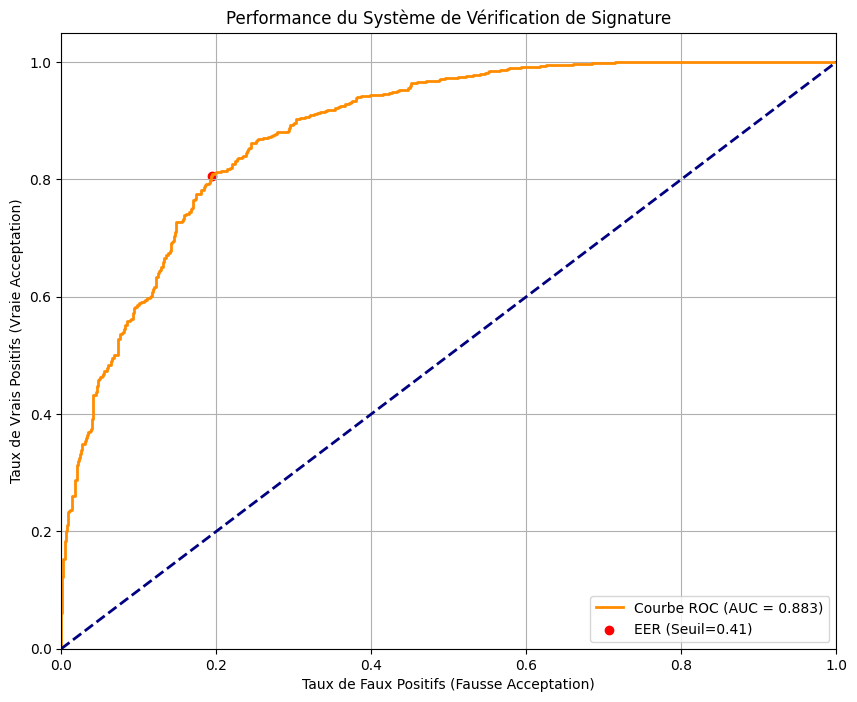

In [ ]:
# --- Cellule 11: Tracé de la Courbe ROC et Calibration ---

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, accuracy_score
import itertools

def generate_evaluation_pairs(data_dir, num_pairs_per_author=20):
    """
    Génère une liste équilibrée de paires (img1, img2) avec leur label (1=Même, 0=Différent).
    """
    pairs = []
    labels = []
    
    # Lister tous les auteurs
    authors = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]
    print(f"Génération des paires pour l'évaluation sur {len(authors)} auteurs...")

    for author in authors:
        author_path = os.path.join(data_dir, author)
        my_sigs = glob.glob(os.path.join(author_path, "*.png"))
        
        if len(my_sigs) < 2: continue

        # Paires Positives (Même auteur) 
        # On génère toutes les combinaisons possibles (ou un sous-ensemble)
        possible_positives = list(itertools.combinations(my_sigs, 2))
        # On en prend un nombre limité pour ne pas surcharger
        selected_positives = random.sample(possible_positives, min(len(possible_positives), num_pairs_per_author))
        
        for p1, p2 in selected_positives:
            pairs.append((p1, p2))
            labels.append(1) # 1 = Authentique

        # Paires Négatives (Imposteurs) 
        # Pour chaque positive, on crée une négative pour équilibrer
        for _ in range(len(selected_positives)):
            # Choisir un AUTRE auteur au hasard
            other_author = author
            while other_author == author:
                other_author = random.choice(authors)
            
            other_sigs = glob.glob(os.path.join(data_dir, other_author, "*.png"))
            if not other_sigs: continue
                
            # Une signature de moi vs une signature de l'autre
            p1 = random.choice(my_sigs)
            p2 = random.choice(other_sigs)
            
            pairs.append((p1, p2))
            labels.append(0) # 0 = Imposteur

    return pairs, labels

def compute_distances(pairs, model):
    """Calcule la distance euclidienne pour chaque paire."""
    distances = []
    print(f"Calcul des distances pour {len(pairs)} paires...")
    
    # On pourrait batcher pour aller plus vite, mais la boucle simple est plus lisible
    for i, (path1, path2) in enumerate(pairs):
        if i % 100 == 0: print(f"Traitement paire {i}/{len(pairs)}", end='\r')
        
        emb1 = calculate_embedding(path1, model)
        emb2 = calculate_embedding(path2, model)
        
        dist = np.linalg.norm(emb1 - emb2)
        distances.append(dist)
        
    print("Calcul terminé.")
    return np.array(distances)


# Charger le modèle (si pas déjà fait)
if 'production_encoder' not in globals():
    production_encoder = tf.keras.models.load_model(MODEL_PATH, compile=False, safe_mode=False)

# Générer les données de test
pairs, y_true = generate_evaluation_pairs(VALID_DIR, num_pairs_per_author=50)

# Calculer les scores (distances)
y_distances = compute_distances(pairs, production_encoder)

# Calculer la ROC
# Attention : roc_curve s'attend à ce que "score élevé" = "classe 1 (authentique)".
# Or, chez nous, "distance faible" = "authentique".
# Nous devons donc inverser les distances (ou prendre leur opposé) pour le calcul.
fpr, tpr, thresholds = roc_curve(y_true, -y_distances) 
roc_auc = auc(fpr, tpr)

# Trouver le seuil optimal (Equal Error Rate - EER)
# C'est le point où (1 - TPR) est le plus proche de FPR
fnr = 1 - tpr
eer_index = np.nanargmin(np.absolute((fnr - fpr)))
optimal_threshold = -thresholds[eer_index] 
eer_value = fpr[eer_index]

print(f"\n--- RÉSULTATS DE L'ÉVALUATION ---")
print(f"Nombre total de paires testées : {len(y_true)}")
print(f"AUC (Area Under Curve) : {roc_auc:.4f} (1.0 est parfait)")
print(f"EER (Equal Error Rate) : {eer_value:.4f}")
print(f"==> SEUIL OPTIMAL SUGGÉRÉ : {optimal_threshold:.4f}")

# Tracer de la courbe ROC
plt.figure(figsize=(10, 8))



plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.scatter(fpr[eer_index], tpr[eer_index], marker='o', color='red', label=f'EER (Seuil={optimal_threshold:.2f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de Faux Positifs (Fausse Acceptation)')
plt.ylabel('Taux de Vrais Positifs (Vraie Acceptation)')
plt.title('Performance du Système de Vérification de Signature')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Résultats :**

```
Nombre total de paires testées : 1400
AUC (Area Under Curve) : 0.8830 (1.0 est parfait)
EER (Equal Error Rate) : 0.1943
==> SEUIL OPTIMAL SUGGÉRÉ : 0.4123
```

- L'allure générale de la courbe (L'AUC : 0.8830) 

Visuellement, la ligne orange se situe bien au-dessus de la ligne pointillée bleue (qui représente un choix au hasard, comme jouer à pile ou face). Elle s'arrondit vers le coin supérieur gauche, ce qui est exactement le comportement recherché.\
Mathématiquement, l'aire sous cette courbe (AUC) est de 0.883.\
Cela signifie que si le système prend au hasard une vraie paire de signatures et une paire d'imposteurs, il a 88,3 % de chances de donner un meilleur score (une distance plus faible) à la vraie paire. C'est un "bon" score pour un prototype rapide (avec 10 ou 15 époques), mais pour de la biométrie en production, on cherche généralement à "pousser" cette courbe orange pour atteindre une AUC supérieure à 0.95.


- Problème : L'EER à 0.1943

Le point rouge sur le graphique marque l'endroit exact où le compromis entre les deux types d'erreurs est équilibré. Si on regarde l'axe horizontal (Fausse Acceptation), ce point tombe à peu près sur 0.19. Si on regarde l'axe vertical (Vraie Acceptation), il tombe vers 0.81 (ce qui signifie un taux de Faux Rejet de 1 - 0.81 = 0.19).

C'est le point le plus important de l'analyse. Il indique qu'au meilleur de ses capacités actuelles, notre système se trompe dans environ 1 cas sur 5. Il laissera passer un imposteur dans 19,4 % des cas, et il bloquera le vrai propriétaire dans 19,4 % des cas.

- Le Seuil Optimal (0.4123)

C'est la valeur "cachée" derrière le point rouge. Pour obtenir ce taux d'erreur de 19,4 %, l'algorithme a calculé qu'on devait régler la limite d'acceptation de notre système à une distance euclidienne de 0.41.

Si on descend ce seuil à 0.20 (pour être plus strict), on se déplacera vers la gauche sur la courbe orange : on n'aura presque plus d'imposteurs (Fausse Acceptation proche de 0), mais notre Vraie Acceptation chutera vers 0.70 (on rejettera 30 % des vrais utilisateurs).

**Bilan Pratique**

Notre architecture neuronale fonctionne et a compris la tâche : elle parvient bien à faire la différence entre les écritures dans la grande majorité des cas. Cependant, un taux d'erreur de près de 20 % indique que le modèle n'a pas encore fini d'apprendre ou qu'il manque de subtilité (ce qui explique pourquoi l'utilisateur 056 a été rejeté lors de notre test précédent).